## Install Dependencies

In [ ]:
!uv pip install -U syftbox-enclave syft-rds==0.1.1-dev.5

# Remote Data Science Flow: Department of Health & National Treasury 

This notebook demonstrates a secure data sharing scenario where:

- **Data Owner**: Department of Health (data.governance@health.gov.uk)
- **Data Scientist**: Treasury Analytics (analytics@treasury.gov.uk)

**Dataset**: Department of Health's records including service encounters and prescription events. The data enables Treasury analysts to perform aggregate analysis on healthcare costs and activity without exposing individual-level data.

**Use Case**: Treasury needs to analyze healthcare expenditure patterns, regional cost variations, and prescription spending to inform budget planning and policy decisions.

---
# 0. Both department install SyftBox on their premise & the syft-rds app

Nothing here to show.

---
# 1. Department of Health Uploads the Dataset

The Department of Health data team creates:
- a dataset containing health records for Treasury analysis
- a mock counterpart
- a data card explaining the schema and data collection

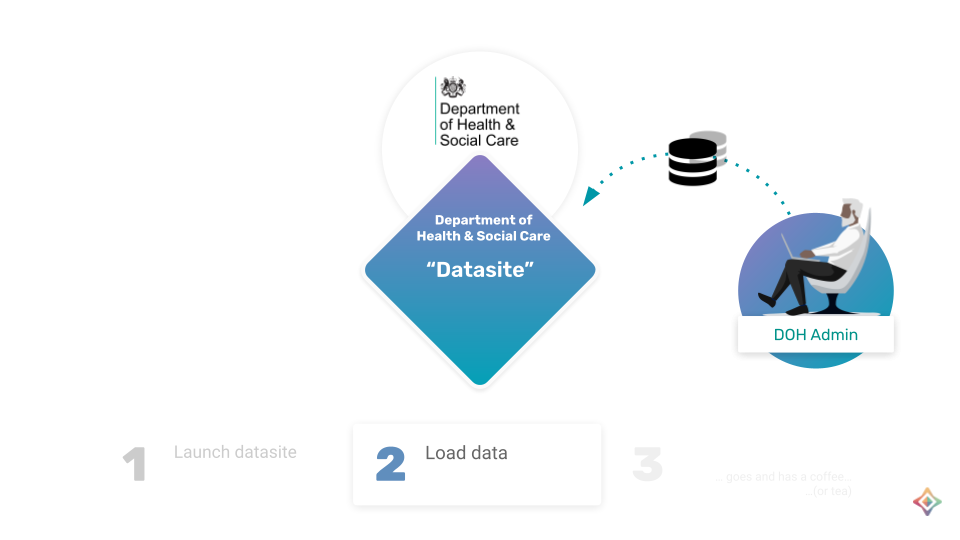

---
# 2. Research from Treasury accesses the dataset

Treasury analytics team can view available datasets and access mock data for development and testing of their analysis code.

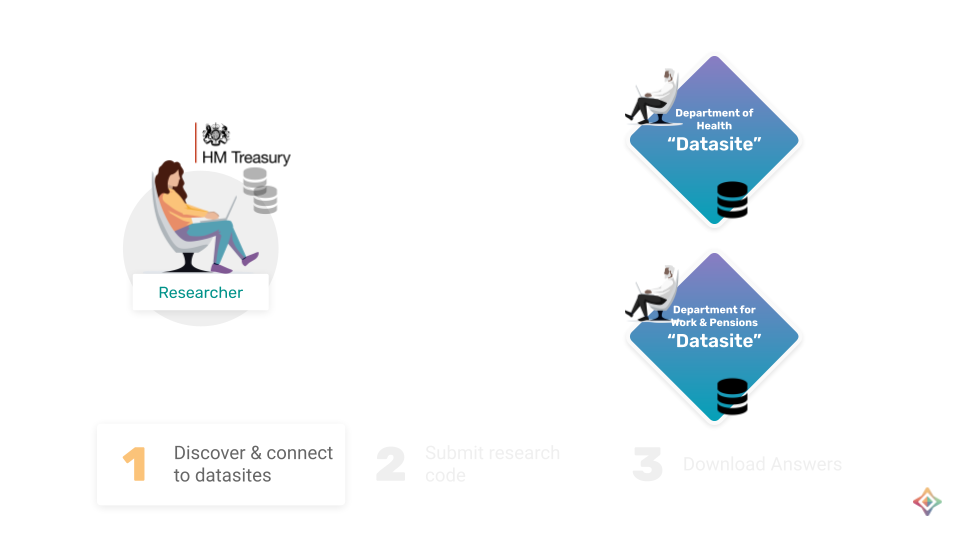

In [ ]:
from syft_rds import init_session
from syft_core import Client

In [ ]:
DATA_OWNERS = [
            Client.load().email
              ]
DATA_SCIENTIST = [ Client.load().email ]

In [ ]:
ds_clients = []

for do in DATA_OWNERS:
    ds_client = init_session(do)
    ds_clients.append(ds_client)
    print(f"Logged into {ds_client.host}")


In [ ]:
datasets = []

# We could either index the datasets
for ds_client in ds_clients:
    datasets.append(ds_client.datasets[0])
    
    

In [ ]:
datasets

### Inspect the data and inform their analysis



In [ ]:
# Inspect the mock data of all datasets

import pandas as pd
from pathlib import Path
from IPython.display import display

for dataset in datasets:
    mock_path = dataset.get_mock_path()
    mock_csv_path = list(Path(mock_path).glob("*.csv"))[0]
    df_mock = pd.read_csv(mock_csv_path, parse_dates=['event_date'])
    
    display(f"Record types: {df_mock['record_type'].unique()}")
    display(f"Regions: {df_mock['region_code'].unique()}")
    
    display(df_mock.head(3))
    print("\n\n\n")
    

### Propose analysis

In [ ]:

code_path = Path(".") / "code"
code_path.mkdir(exist_ok=True)

code_file_name  = "dh_analysis.py"
code_file_path = code_path / code_file_name

In [ ]:
%%writefile {code_file_path}

import os
import pandas as pd
from pathlib import Path
import json

DATA_DIR = os.environ["DATA_DIR"]
OUTPUT_DIR = os.environ["OUTPUT_DIR"]

print("Treasury Analytics: Department of Health Records Analysis")
print("=" * 55)

# Load the DH raw records dataset
dataset_paths =  [ dataset_path for dataset_path in DATA_DIR.split(",")]
csv_paths = []
for dataset_path in dataset_paths:
    csv_paths.extend(list(Path(dataset_path).glob("*.csv")))
                     
# Combine all CSVs into one DataFrame
df = pd.concat((pd.read_csv(csv, parse_dates=['event_date']) for csv in csv_paths), ignore_index=True)

print(f"Loaded {len(df)} health records for analysis")
print(f"Date range: {df['event_date'].min()} to {df['event_date'].max()}")

# Analysis 1: Healthcare costs by region
print("\n1. Healthcare Costs by NHS Region:")
encounter_costs = df[df['record_type'] == 'encounter'].groupby('region_code').agg({
    'cost_gbp': ['sum', 'mean', 'count']
}).round(2)
encounter_costs.columns = ['Total_Cost_GBP', 'Avg_Cost_GBP', 'Total_Encounters']
print(encounter_costs)

# Analysis 2: Prescription costs by BNF chapter
print("\n2. Prescription Costs by Drug Category:")
prescription_costs = df[df['record_type'] == 'prescription'].groupby('bnf_chapter').agg({
    'prescription_cost_gbp': ['sum', 'mean', 'count'],
    'item_count': 'sum'
}).round(2)
prescription_costs.columns = ['Total_Prescription_Cost_GBP', 'Avg_Prescription_Cost_GBP', 'Total_Prescriptions', 'Total_Items']
print(prescription_costs)

# Analysis 3: Activity by encounter type
print("\n3. Healthcare Activity by Service Type:")
activity_summary = df[df['record_type'] == 'encounter'].groupby('encounter_type').agg({
    'record_id': 'count',
    'cost_gbp': 'sum',
    'length_of_stay_days': 'mean'
}).round(2)
activity_summary.columns = ['Total_Encounters', 'Total_Cost_GBP', 'Avg_Length_of_Stay']
print(activity_summary)

# Save aggregate results for Treasury reporting
results = {
    "total_healthcare_cost": float(df[df['record_type'] == 'encounter']['cost_gbp'].sum()),
    "total_prescription_cost": float(df[df['record_type'] == 'prescription']['prescription_cost_gbp'].sum()),
    "total_encounters": int(df[df['record_type'] == 'encounter'].shape[0]),
    "total_prescriptions": int(df[df['record_type'] == 'prescription'].shape[0]),
    "cost_by_region": encounter_costs.to_dict(),
    "prescription_costs_by_category": prescription_costs.to_dict(),
    "activity_by_service_type": activity_summary.to_dict()
}

# Write summary report
with open(os.path.join(OUTPUT_DIR, "treasury_health_analysis_summary.json"), "w") as f:
    json.dump(results, f, indent=2)

# Write detailed CSV reports
encounter_costs.to_csv(os.path.join(OUTPUT_DIR, "costs_by_region.csv"))
prescription_costs.to_csv(os.path.join(OUTPUT_DIR, "prescription_costs_by_category.csv"))
activity_summary.to_csv(os.path.join(OUTPUT_DIR, "activity_by_service_type.csv"))

print(f"\n✅ Analysis complete. Total healthcare expenditure: £{results['total_healthcare_cost']:,.2f}")
print(f"✅ Total prescription expenditure: £{results['total_prescription_cost']:,.2f}")


### Test the analysis code against mock data

Before submitting the code for review, Treasury can test their analysis against the Department of Health mock data to ensure it works correctly.


In [ ]:
# Test against mock of all datasets

import subprocess, tempfile, os

with tempfile.TemporaryDirectory() as temp_dir:
    env = os.environ.copy()
    env.update({'DATA_DIR': ",".join([ str(dataset.get_mock_path()) for dataset in datasets]), 'OUTPUT_DIR': temp_dir})
    
    result = subprocess.run(["python", str(code_file_path)], env=env, capture_output=True, text=True)
    print(result.stdout)

---
# 3. Treasury submits analysis code for review

Treasury analyst submits their healthcare expenditure analysis code to be reviewed by Department of Health data governance team before execution on private data.

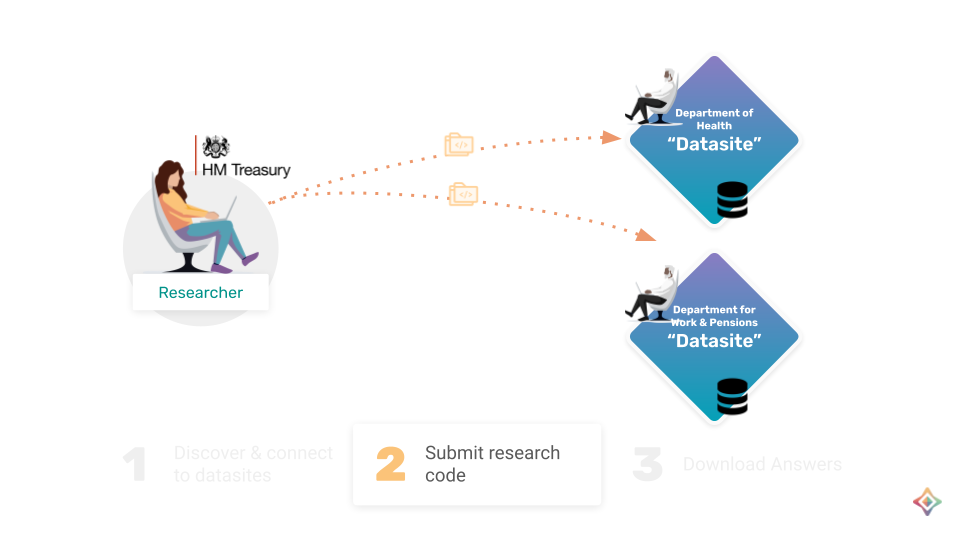

In [ ]:
from uuid import uuid4

# Generate 
RANDOM_ID = str(uuid4())[0:8]
JOB_NAME = f"Test Job - {RANDOM_ID}"

print("Job Name:", JOB_NAME)

In [ ]:
ENCLAVE = "enclave-ndl-gov-data@openmined.org"

jobs = []

for ds_client, dataset in zip(ds_clients, datasets):
    job = ds_client.jobs.submit(
                name=JOB_NAME,
                description="NDL Gov Data Experiment",
                user_code_path=code_path,
                dataset_name=dataset.name,
                entrypoint = code_file_name,
                enclave = ENCLAVE
            )
    job.describe()
    jobs.append(job)

In [ ]:
ds_clients[0].jobs.get(name=JOB_NAME).describe()

---
# 4. Department of Health reviews the code

DH data governance team reviews Treasury's analysis code to ensure it meets privacy and security requirements before allowing execution on sensitive health data.

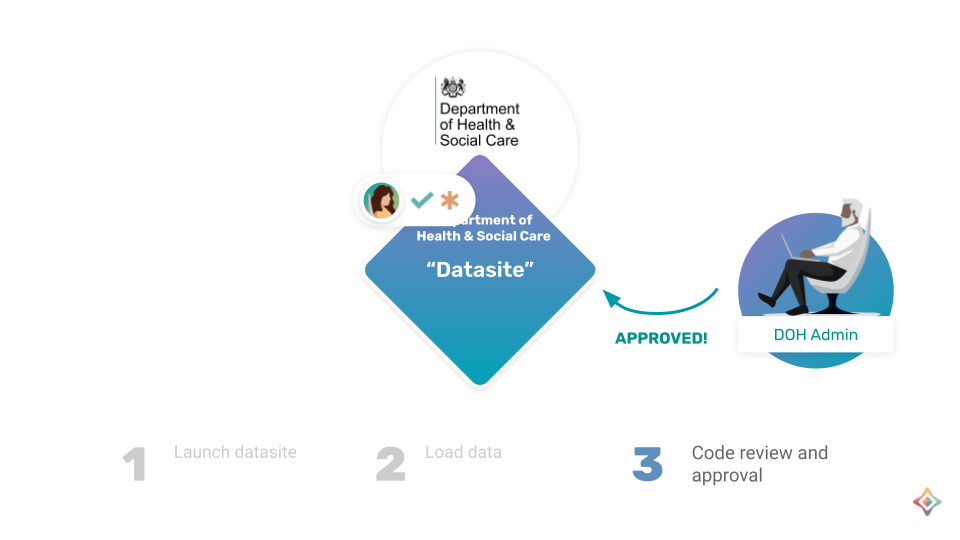

## Enclave Client

In [ ]:
from syftbox_enclave import connect

In [ ]:
enclave_client = connect(ENCLAVE)

In [ ]:
PROJECT_NAME = f"Test Project - {RANDOM_ID}"

print("Project Name:", PROJECT_NAME)

In [ ]:
datasets

In [ ]:

proj_res = enclave_client.create_project(
                   project_name = PROJECT_NAME,
                   datasets = datasets,
                   output_owners = DATA_OWNERS + DATA_SCIENTIST,
                   code_path = code_path,
                   entrypoint = code_file_name,
            )

In [ ]:
proj_res.status(block=True)

In [ ]:
# Force Start if atleast one of the datasites have approved
# proj_res.force_start()

---
# 5. Treasury accesses approved results

After DH approval and execution, Treasury can access the aggregated analysis results for their budget planning and policy work.

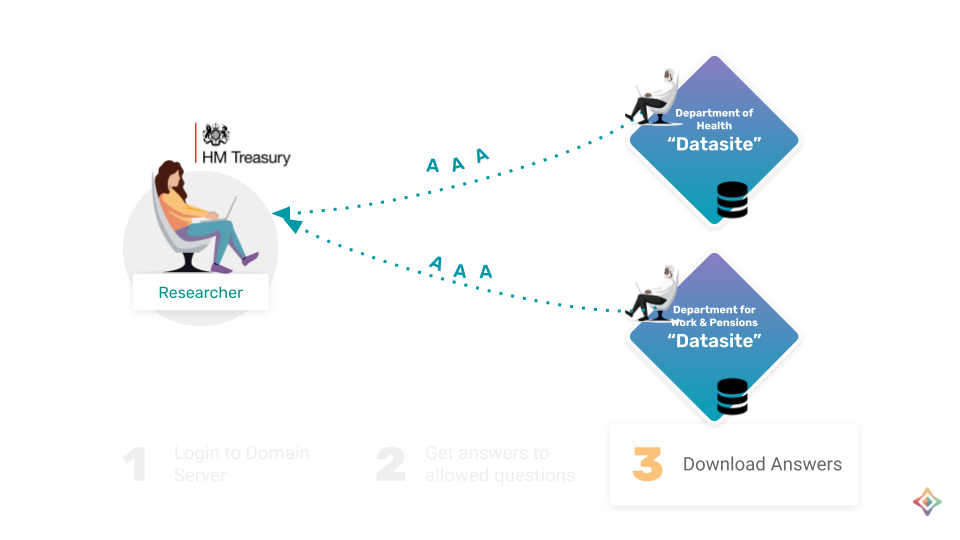

In [ ]:
# Wait until the project is ready
proj_res_path = proj_res.output(block=True)

In [ ]:
import matplotlib.pyplot as plt
import json
import pandas as pd

# Set up the plotting style
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Treasury Analytics: Department of Health Expenditure Analysis', fontsize=16, fontweight='bold')


results_json_path = proj_res_path / 'treasury_health_analysis_summary.json'
# Load the results
if results_json_path.exists():
    # Parse the JSON data
    f = open(results_json_path, 'r')  # Manually open the file
    results_json = json.load(f) 
    
    # Chart 1: Healthcare Costs by NHS Region
    region_data = pd.DataFrame(results_json['cost_by_region'])
    ax1 = axes[0, 0]
    bars1 = ax1.bar(region_data.index, region_data['Total_Cost_GBP'], 
                    color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F'])
    ax1.set_title('Healthcare Costs by NHS Region', fontweight='bold')
    ax1.set_xlabel('NHS Region')
    ax1.set_ylabel('Total Cost (£)')
    ax1.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 10,
                f'£{height:,.0f}', ha='center', va='bottom', fontweight='bold')
    
    # Chart 2: Prescription Costs by Category
    prescription_data = pd.DataFrame(results_json['prescription_costs_by_category'])
    ax2 = axes[0, 1]
    bars2 = ax2.bar(prescription_data.index, prescription_data['Total_Prescription_Cost_GBP'],
                    color=['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6'])
    ax2.set_title('Prescription Costs by Category', fontweight='bold')
    ax2.set_xlabel('BNF Chapter')
    ax2.set_ylabel('Total Prescription Cost (£)')
    ax2.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'£{height:.2f}', ha='center', va='bottom', fontweight='bold')
    
    # Chart 3: Activity by Service Type
    activity_data = pd.DataFrame(results_json['activity_by_service_type'])
    ax3 = axes[1, 0]
    bars3 = ax3.bar(activity_data.index, activity_data['Total_Encounters'],
                    color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC'])
    ax3.set_title('Healthcare Activity by Service Type', fontweight='bold')
    ax3.set_xlabel('Service Type')
    ax3.set_ylabel('Number of Encounters')
    ax3.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars3:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')
    
    # Chart 4: Cost Summary Pie Chart
    ax4 = axes[1, 1]
    total_healthcare = results_json['total_healthcare_cost']
    total_prescription = results_json['total_prescription_cost']
    
    costs = [total_healthcare, total_prescription]
    labels = ['Service Encounters', 'Prescriptions']
    colors = ['#FF6B6B', '#4ECDC4']
    
    wedges, texts, autotexts = ax4.pie(costs, labels=labels, colors=colors, autopct='%1.1f%%',
                                       startangle=90, textprops={'fontweight': 'bold'})
    ax4.set_title('Total Healthcare Expenditure Breakdown', fontweight='bold')
    
    # Add total cost in center
    total_cost = total_healthcare + total_prescription
    ax4.text(0, 0, f'Total\n£{total_cost:,.2f}', ha='center', va='center', 
             fontsize=12, fontweight='bold', 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    plt.tight_layout()
    plt.show()
    
else:
    print("No analysis results available to visualize.")
